# RM-294 Optimization II - Airline Ticket Price Dynamic Programming

Suppose an airline wants to choose what price to set its tickets, given two ticket classes (coach, first class). Coach has three price options (low, medium, and high), while first class has two prices (low and high).


Customers who buy a ticket may not show up to their own flight. Then, the airline may choose to overbook for coach seats, subject to overbooking costs, this could be bumping people up from coach to first class or paying them a fee.

Each day, only up to one ticket is sold in each of coach and first class. If first class if fully booked, the chance of sale in coach increase by 4%.

Suppose The following:  

– You have 365 days to sell tickets  
– There are 100 seasts in coach, initially we can oversell 5 coach seats  
– 20 seats in first class  
– $P$(coach customer shows up) = 0.95  
– $P$(first class customer shows up) = 0.97  
– Price for coach tickets is low, medium, or high. That is $p_{coach} \in [l_c, m_c, h_c]$, $p_{coach} \in [300, 325, 350]$  
– Price for first class tickets is low or high. That is $p_{first\ class} \in [l_{f}, h_{f}]$, $p_{first\ class} \in [425, 500]$


– The expected demand for each coach price is: $\mathbb{E}(d_{l_c}) = 0.65$, $\mathbb{E}(d_{m_c}) = 0.45$, and $\mathbb{E}(d_{h_c}) = 0.30$  
– The expected demand for each first class price is: $\mathbb{E}(d_{l_{f}}) = 0.08$ and $\mathbb{E}(d_{h_{f}}) = 0.04$  
– The cost of overbooking, $c$, is $50 to upgrade a coach ticket to first class and $425 to bump a coach ticket off the plane.  
– Discount rate, $r$, is 17% per year

---

### 1. Expected Discounted Profit

In [27]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
from collections import Counter

In [28]:
# a. Terminal condition

def calculate_terminal_costs(tickets_sold, max_tickets, show_up_rate):
    """
    Calculate the expected overbooking cost on departure day (t=365) using the binomial distribution.

    On departure, each ticket holder shows up independently. If more coach passengers show up
    than there are seats, the airline first bumps them up to available first-class seats ($50 each),
    then pays to bump remaining passengers off the flight entirely ($425 each).

    Parameters:
    - tickets_sold: dict, number of tickets sold per class (e.g., {"coach": 110, "first": 20}).
    - max_tickets: dict, seat capacity per class (e.g., {"coach": 100, "first": 20}).
    - show_up_rate: dict, probability each ticket holder shows up per class (e.g., {"coach": 0.95, "first": 0.97}).

    Returns:
    - float: expected overbooking cost across all possible show-up outcomes.
    """

    # Create a list of each possible situation (no one shows up to everyone shows up) for each ticket class
    k_c = np.arange(0, tickets_sold["coach"] + 1)
    k_f = np.arange(0, tickets_sold["first"] + 1)

    # Get the probability mass functions for coach and first class
    pmf_c = scipy.stats.binom.pmf(k_c, tickets_sold["coach"], show_up_rate["coach"])
    pmf_f = scipy.stats.binom.pmf(k_f, tickets_sold["first"], show_up_rate["first"])

    expected_cost = 0

    # Sum over every possibilty of attendance:
    for i in k_c:
        for j in k_f:
            joint_probability = pmf_c[i] * pmf_f[j]

            # Find the number of overbooked tickets we upgrade or kick off the plane
            open_firstclass_seats = max_tickets["first"] - j
            overbooked_seats = max(i - max_tickets["coach"], 0)
            upgraded_seats = min(overbooked_seats, open_firstclass_seats)
            bumped_off_plane = overbooked_seats - upgraded_seats

            # Add the expected cost of this scenario to the running total
            expected_cost += joint_probability * (upgraded_seats * 50 + 425 * bumped_off_plane)

    return expected_cost

In [29]:
def expected_profit(t, tickets_sold, ticket_prices, ticket_demand, delta, show_up_rate, max_tickets, overbook, coach_sale_optional=False):
    """
    Compute the maximum expected discounted profit from time t onward, given the
    number of coach and first-class tickets already sold.

    Uses the Bellman equation recursively, choosing the optimal coach and first-class prices
    to maximize expected revenue minus discounted future overbooking costs.

    Parameters:
    - t: int, current day (0 to 365). Day 365 is departure.
    - tickets_sold: Dictionary containing the number of tickets sold for each class (e.g., {"coach": 110, "first": 20}).
    - ticket_prices: Dictionary containing the lists of price options for each ticket (e.g., {"coach": [300, 325], "first": [425, 500]}).
    - ticket_demand: Dictionary containing the lists of demands for each ticket option (e.g., {"coach": [0.65, 0.45], "first": [0.08, 0.04]}).
    - delta: float, daily discount factor (e.g., 1/(1 + 0.17/365)).
    - show_up_rate: Dictionary containing the show-up probability per class (e.g., {"coach": 0.95, "first": 0.97}).
    - max_tickets: Dictionary containing the maximum number of seats available for each class (e.g., {"coach": 100, "first": 25}).
    - overbook: int, the number of coach seats that can be overbooked.
    - coach_sale_optional: boolean, determines whether the system can optionally hold back from selling coach seats on a given day.

    Returns:
    - tuple of (float, np.ndarray, np.ndarray):
        - final_expected_profit: maximum expected discounted profit from the given state.
        - value_tensor: 3D array (366 x max_coach_sellable x max_first_sellable) of optimal values at each (day, coach_sold, first_sold) state.
        - choice_tensor: 3D object array of same shape, storing the optimal (coach_price, first_price) tuple at each state.
    """

    # Build coach options: original prices/demands, plus optional no-sale
    coach_prices = list(ticket_prices['coach'])
    coach_demands = list(ticket_demand['coach'])
    if coach_sale_optional:
        coach_prices.append(0)
        coach_demands.append(0.0)

    # If we save each value in a tensor as we calculate it, we can look up the value instead of recomputing
    value_tensor = np.full((366, max_tickets['coach'] + overbook + 1, max_tickets['first'] + 1), np.nan)

    # We can also store the choices at each state
    choice_tensor = np.empty((366, max_tickets['coach'] + overbook + 1, max_tickets['first'] + 1), dtype=object)

    # Since there are only costs on the final day, we can precompute all possible terminal costs
    # as a (max_coach + overbook + 1) x (max_first + 1) matrix
    cost_matrix = np.zeros((max_tickets['coach'] + overbook + 1, max_tickets['first'] + 1))
    for i in range(cost_matrix.shape[0]):
        for j in range(cost_matrix.shape[1]):
            cost_matrix[i, j] = calculate_terminal_costs(tickets_sold={'coach':i,'first':j}, max_tickets=max_tickets, show_up_rate=show_up_rate)

    # The precomputed cost matrix corresponds to the last day's 'slice' of the tensor
    value_tensor[365, :, :] = - cost_matrix

    # Now we loop over each day backwards
    for day in reversed(range(t, 365)):
        for c in range(value_tensor.shape[1]):
            for f in range(value_tensor.shape[2]):

                # for each price combination we find the expected value, then choose the best of those
                # as the value for the value_tensor
                best_val = -np.inf
                best_action = (None, None)

                for ci in range(len(coach_prices)):
                    cp = coach_prices[ci]
                    base_c_prob = coach_demands[ci]

                    for fi in range(len(ticket_prices['first'])):
                        fp = ticket_prices['first'][fi]

                        # Reset probabilities each iteration to avoid carryover from previous loop
                        f_prob = ticket_demand['first'][fi]
                        c_prob = base_c_prob

                        # If coach is maxed out, no more coach tickets can be sold
                        if c >= max_tickets['coach'] + overbook:
                            c_prob = 0

                        # If first class is sold out, no first class tickets can be sold and coach demand increases by 4%
                        if f >= max_tickets['first']:
                            f_prob = 0
                            if c < (max_tickets['coach'] + overbook) and base_c_prob > 0:
                                c_prob = min(c_prob + 0.04, 1.0)
                            else:
                                c_prob = 0

                        # Expected revenue earned today from ticket sales
                        todays_return = c_prob * f_prob * (cp + fp) + c_prob * (1 - f_prob) * cp + (1 - c_prob) * f_prob * fp

                        # Look up tomorrow's value for each possible outcome
                        # s = sale, n = no sale. First letter is coach, second is first class
                        v_nn = value_tensor[day+1, c, f]
                        v_sn = value_tensor[day+1, c+1, f] if c < value_tensor.shape[1] - 1 else v_nn
                        v_ns = value_tensor[day+1, c, f+1] if f < value_tensor.shape[2] - 1 else v_nn
                        v_ss = value_tensor[day+1, c+1, f+1] if (c < value_tensor.shape[1] - 1 and f < value_tensor.shape[2] - 1) else v_nn

                        # Expected future value weighted by the probability of each outcome
                        tomorrows_return = c_prob * f_prob * v_ss \
                            + c_prob * (1 - f_prob) * v_sn \
                            + (1 - c_prob) * f_prob * v_ns \
                            + (1 - c_prob) * (1 - f_prob) * v_nn

                        # Bellman equation: today's revenue + discounted future value
                        current_value = todays_return + delta * tomorrows_return

                        # Keep track of the best price combination
                        if current_value > best_val:
                            best_val = current_value
                            best_action = (cp, fp)

                # Store the optimal value and action for this state
                value_tensor[day, c, f] = best_val
                choice_tensor[day, c, f] = best_action

    # Look up the answer for the specific starting state
    final_expected_profit = value_tensor[t, tickets_sold['coach'], tickets_sold['first']]

    return (final_expected_profit, value_tensor, choice_tensor)

Revisiting the original question:  

What is the expected discounted profit over the course of the year?

In [30]:
q1_result = expected_profit(
    t=0,
    tickets_sold={"coach": 0, "first": 0},
    ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
    ticket_demand={"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]},
    delta=1/(1 + 0.17/365),
    show_up_rate={"coach": 0.95, "first": 0.97},
    max_tickets={"coach": 100, "first": 20},
    overbook=5)

print(f"The expected profit is: {q1_result[0]:.3f}")

The expected profit is: 41909.748


---

### 2. Expected Discount Profit with Varying Overbooking Policy

In [31]:
def q2_run(policy):
    result = expected_profit(
        t=0,
        tickets_sold={"coach": 0, "first": 0},
        ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
        ticket_demand={"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]},
        delta=1/(1 + 0.17/365),
        show_up_rate={"coach": 0.95, "first": 0.97},
        max_tickets={"coach": 100, "first": 20},
        overbook=policy)
    return (policy, result[0])

with ProcessPoolExecutor() as executor:
    q2_profits = dict(executor.map(q2_run, range(5, 21)))

for ob, profit in sorted(q2_profits.items()):
    print(f"Expected profit with overbooking policy of {ob} seats: {profit:.3f}")

best_policy = max(q2_profits, key=q2_profits.get)
best_profit = q2_profits[best_policy]
print(f"\nBest policy: overbook {best_policy} seats with an expected profit of {best_profit:.3f}")

Expected profit with overbooking policy of 5 seats: 41909.748
Expected profit with overbooking policy of 6 seats: 42039.024
Expected profit with overbooking policy of 7 seats: 42117.952
Expected profit with overbooking policy of 8 seats: 42157.769
Expected profit with overbooking policy of 9 seats: 42171.347
Expected profit with overbooking policy of 10 seats: 42169.238
Expected profit with overbooking policy of 11 seats: 42158.860
Expected profit with overbooking policy of 12 seats: 42144.906
Expected profit with overbooking policy of 13 seats: 42130.127
Expected profit with overbooking policy of 14 seats: 42115.881
Expected profit with overbooking policy of 15 seats: 42102.776
Expected profit with overbooking policy of 16 seats: 42091.038
Expected profit with overbooking policy of 17 seats: 42080.720
Expected profit with overbooking policy of 18 seats: 42071.785
Expected profit with overbooking policy of 19 seats: 42064.146
Expected profit with overbooking policy of 20 seats: 42057.6

In [32]:
# ── Q3 Policy: No-Sale Option — Sweep Overbooking Levels ─────────────────────
# Find Q3's optimal hard cap. The no-sale option lets the airline self-regulate
# each day, so diminishing returns from a higher cap are expected to set in later
# than under Q2.

def q3_run(ob):
    """Solve the no-sale DP for a single overbooking level. Mirrors q2_run."""
    result = expected_profit(
        t=0, tickets_sold={"coach": 0, "first": 0},
        ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
        ticket_demand={"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]},
        delta=1/(1 + 0.17/365), show_up_rate={"coach": 0.95, "first": 0.97},
        max_tickets={"coach": 100, "first": 20},
        overbook=ob, coach_sale_optional=True)
    return (ob, result[0])

with ProcessPoolExecutor() as executor:
    q3_profits = dict(executor.map(q3_run, range(5, 31)))

for ob, profit in sorted(q3_profits.items()):
    print(f"  overbook={ob}: ${profit:.3f}")

best_q3_policy = max(q3_profits, key=q3_profits.get)
best_q3_profit = q3_profits[best_q3_policy]
print(f"\nBest Q3 (no-sale) policy: overbook={best_q3_policy}, profit=${best_q3_profit:.3f}")

  overbook=5: $41909.748
  overbook=6: $42039.024
  overbook=7: $42117.952
  overbook=8: $42157.769
  overbook=9: $42171.347
  overbook=10: $42175.196
  overbook=11: $42176.507
  overbook=12: $42176.930
  overbook=13: $42177.067
  overbook=14: $42177.113
  overbook=15: $42177.129
  overbook=16: $42177.134
  overbook=17: $42177.136
  overbook=18: $42177.136
  overbook=19: $42177.137
  overbook=20: $42177.137
  overbook=21: $42177.137
  overbook=22: $42177.137
  overbook=23: $42177.137
  overbook=24: $42177.137
  overbook=25: $42177.137
  overbook=26: $42177.137
  overbook=27: $42177.137
  overbook=28: $42177.137
  overbook=29: $42177.137
  overbook=30: $42177.137

Best Q3 (no-sale) policy: overbook=28, profit=$42177.137


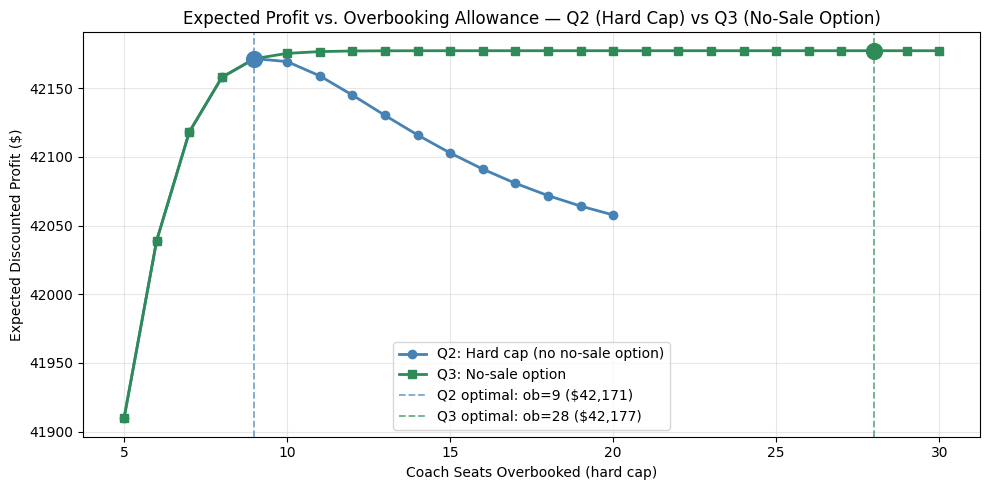

Q2 optimal: ob=9,    profit=$42,171.347
Q3 optimal: ob=28, profit=$42,177.137
Q3 advantage at respective optima: $+5.79


In [33]:
# ── Expected Profit vs. Overbooking Allowance — Q2 vs Q3 ─────────────────────
# Q2 sweeps ob=5-20; Q3 sweeps ob=5-30 (wider range since the no-sale option
# lets the airline self-regulate, so a higher hard cap is less risky).

fig, ax = plt.subplots(figsize=(10, 5))

obs_q2 = sorted(q2_profits)
obs_q3 = sorted(q3_profits)

ax.plot(obs_q2, [q2_profits[o] for o in obs_q2], 'o-', color='steelblue',
        linewidth=2, markersize=6, label='Q2: Hard cap (no no-sale option)')
ax.plot(obs_q3, [q3_profits[o] for o in obs_q3], 's-', color='seagreen',
        linewidth=2, markersize=6, label='Q3: No-sale option')

ax.scatter([best_policy],    [best_profit],    color='steelblue', s=130, zorder=5)
ax.scatter([best_q3_policy], [best_q3_profit], color='seagreen',  s=130, zorder=5)
ax.axvline(best_policy,    color='steelblue', linestyle='--', linewidth=1.3, alpha=0.7,
           label=f'Q2 optimal: ob={best_policy} (${best_profit:,.0f})')
ax.axvline(best_q3_policy, color='seagreen',  linestyle='--', linewidth=1.3, alpha=0.7,
           label=f'Q3 optimal: ob={best_q3_policy} (${best_q3_profit:,.0f})')

ax.set_xlabel('Coach Seats Overbooked (hard cap)')
ax.set_ylabel('Expected Discounted Profit ($)')
ax.set_title('Expected Profit vs. Overbooking Allowance — Q2 (Hard Cap) vs Q3 (No-Sale Option)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Q2 optimal: ob={best_policy},    profit=${best_profit:,.3f}")
print(f"Q3 optimal: ob={best_q3_policy}, profit=${best_q3_profit:,.3f}")
print(f"Q3 advantage at respective optima: ${best_q3_profit - best_profit:+,.2f}")

---

### 3. Comparing with a Coach No-Sale Policy

In [34]:
q3_result = expected_profit(
    t=0,
    tickets_sold={"coach": 0, "first": 0},
    ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
    ticket_demand={"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]},
    delta=1/(1 + 0.17/365),
    show_up_rate={"coach": 0.95, "first": 0.97},
    max_tickets={"coach": 100, "first": 20},
    overbook=30,
    coach_sale_optional=True)

print(f"The expected profit is: {q3_result[0]:.3f}")

The expected profit is: 42177.137


We changed the number of available seats to overbook, so let's check the original policy also allowing 30 seats overbooked

In [35]:
# Baseline: same overbook cap (30) but without the no-sale option, to isolate the option's value
q3_hardcap30_result = expected_profit(
    t=0,
    tickets_sold={"coach": 0, "first": 0},
    ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
    ticket_demand={"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]},
    delta=1/(1 + 0.17/365),
    show_up_rate={"coach": 0.95, "first": 0.97},
    max_tickets={"coach": 100, "first": 20},
    overbook=30,
    coach_sale_optional=False)

print(f"Hard cap (overbook=30, no no-sale option): ${q3_hardcap30_result[0]:.3f}")

Hard cap (overbook=30, no no-sale option): $42032.812


Comparing the results, we can see that indeed allowing a fourth option increases the expected profit. If we compare it to the best policy from (2), which allowed 9 seats overbooked without making coach seat selling optional, the gain is only $5.79, or 0.0137%. This gain is small, but still objectively larger.

To isolate the effect of the no-sale option from the effect of the higher cap, we also ran the Q2 policy at overbook=30, for an expected profit of $42,032.81. Adding the no-sale option at the same cap gives $42,177.14, a gain of $144.32, or 0.34%. This is the pure benefit of the no-sale option.

The no-sale option can never decrease expected profit because the original decision set is a subset of the expanded one. The optimizer can always ignore the new option and recover the old policy, so it does at least as well.

---

### 4. Sensitivity Analysis

In [36]:
base_coach_demand = [0.65, 0.45, 0.30]
base_first_demand = [0.08, 0.04]

coach_perturbations = np.arange(-0.15, 0.16, 0.01)
first_perturbations = np.arange(-0.15, 0.16, 0.01)

In [37]:
# def sensitivity_run_q2(args):
#     cp, fp = args
#     perturbed_coach = [min(max(d + cp, 0), 1) for d in base_coach_demand]
#     perturbed_first = [min(max(d + fp, 0), 1) for d in base_first_demand]
#     result = expected_profit(
#         t=0,
#         tickets_sold={"coach": 0, "first": 0},
#         ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
#         ticket_demand={"coach": perturbed_coach, "first": perturbed_first},
#         delta=1/(1 + 0.17/365),
#         show_up_rate={"coach": 0.95, "first": 0.97},
#         max_tickets={"coach": 100, "first": 20},
#         overbook=best_policy,
#         coach_sale_optional=False)
#     return (cp, fp, result[0])

# def sensitivity_run_q3(args):
#     cp, fp = args
#     perturbed_coach = [min(max(d + cp, 0), 1) for d in base_coach_demand]
#     perturbed_first = [min(max(d + fp, 0), 1) for d in base_first_demand]
#     result = expected_profit(
#         t=0,
#         tickets_sold={"coach": 0, "first": 0},
#         ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
#         ticket_demand={"coach": perturbed_coach, "first": perturbed_first},
#         delta=1/(1 + 0.17/365),
#         show_up_rate={"coach": 0.95, "first": 0.97},
#         max_tickets={"coach": 100, "first": 20},
#         overbook=30,
#         coach_sale_optional=True)
#     return (cp, fp, result[0])

In [38]:
# args_list = [(cp, fp) for cp in coach_perturbations for fp in first_perturbations]

# with ProcessPoolExecutor() as executor:
#     results_q2 = list(executor.map(sensitivity_run_q2, args_list))
#     results_q3 = list(executor.map(sensitivity_run_q3, args_list))

# profit_grid_q2 = np.zeros((len(coach_perturbations), len(first_perturbations)))
# profit_grid_q3 = np.zeros((len(coach_perturbations), len(first_perturbations)))

# for cp, fp, profit in results_q2:
#     i = np.argmin(np.abs(coach_perturbations - cp))
#     j = np.argmin(np.abs(first_perturbations - fp))
#     profit_grid_q2[i, j] = profit

# for cp, fp, profit in results_q3:
#     i = np.argmin(np.abs(coach_perturbations - cp))
#     j = np.argmin(np.abs(first_perturbations - fp))
#     profit_grid_q3[i, j] = profit

# print("Q2 Policy (hard cap):")
# print(f"  Min profit: {profit_grid_q2.min():.3f}")
# print(f"  Max profit: {profit_grid_q2.max():.3f}")
# print(f"  Base profit: {profit_grid_q2[len(coach_perturbations)//2, len(first_perturbations)//2]:.3f}")

# print("\nQ3 Policy (no-sale option):")
# print(f"  Min profit: {profit_grid_q3.min():.3f}")
# print(f"  Max profit: {profit_grid_q3.max():.3f}")
# print(f"  Base profit: {profit_grid_q3[len(coach_perturbations)//2, len(first_perturbations)//2]:.3f}")

In [39]:
# np.save('profit_grid_q2.npy', profit_grid_q2)
# np.save('profit_grid_q3.npy', profit_grid_q3)

In [40]:
profit_grid_q2 = np.load('profit_grid_q2.npy')
profit_grid_q3 = np.load('profit_grid_q3.npy')

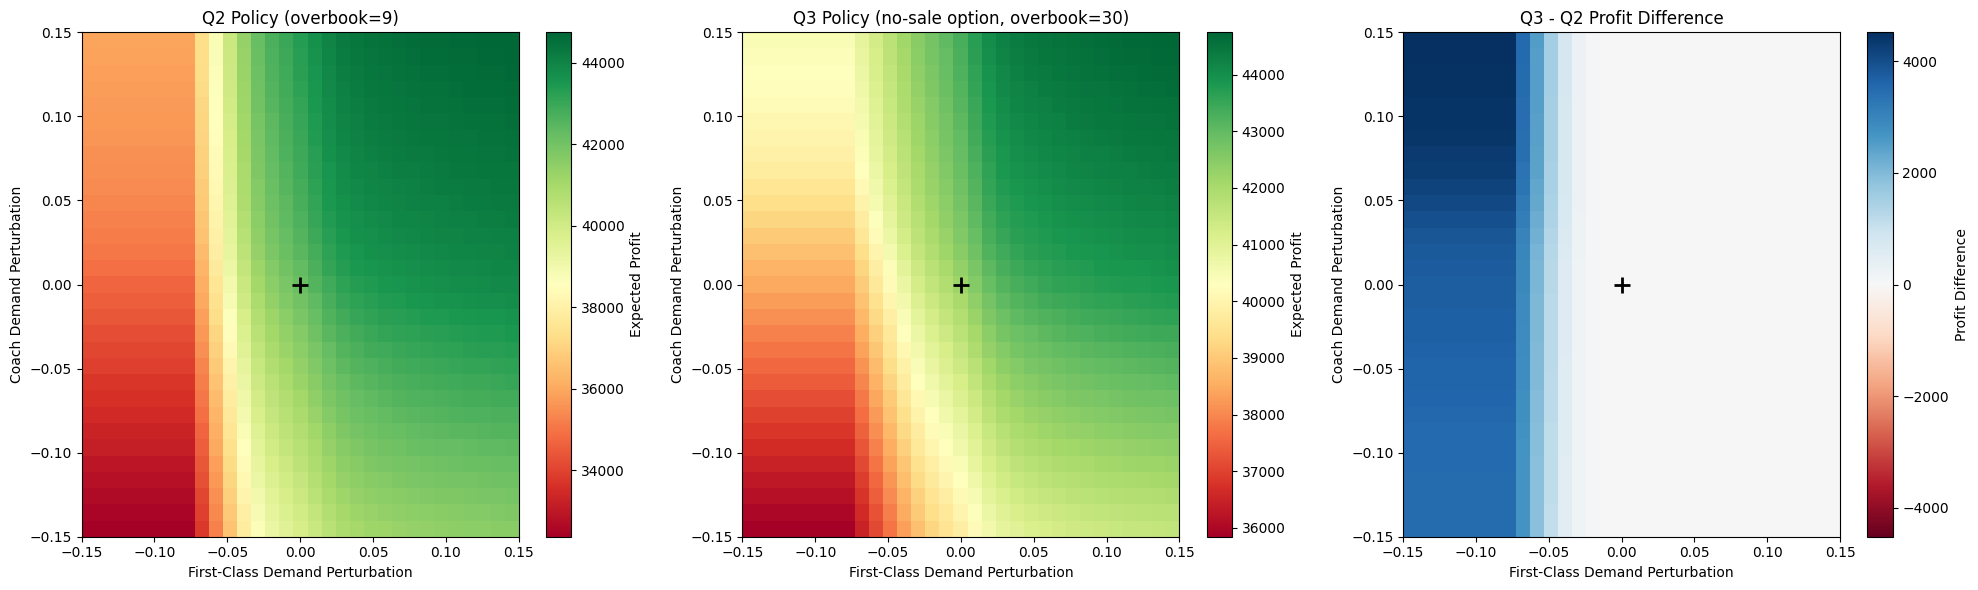

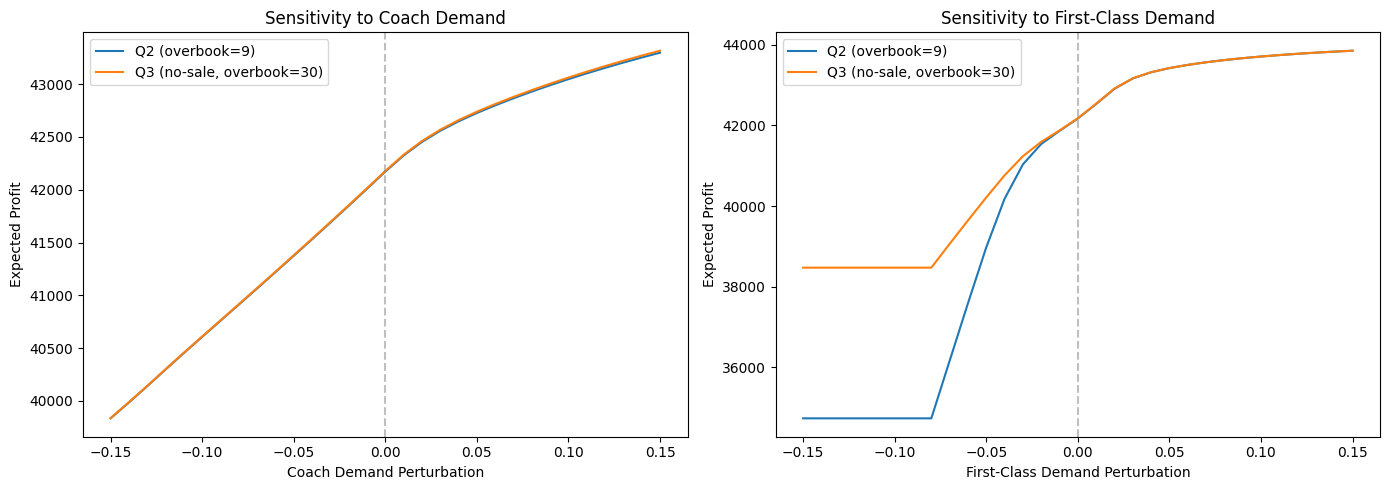

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Q2 heatmap
im0 = axes[0].imshow(profit_grid_q2, origin='lower',
                      extent=[first_perturbations[0], first_perturbations[-1],
                              coach_perturbations[0], coach_perturbations[-1]],
                      aspect='auto', cmap='RdYlGn')
axes[0].set_xlabel('First-Class Demand Perturbation')
axes[0].set_ylabel('Coach Demand Perturbation')
axes[0].set_title(f'Q2 Policy (overbook={best_policy})')
axes[0].plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
plt.colorbar(im0, ax=axes[0], label='Expected Profit')

# Q3 heatmap
im1 = axes[1].imshow(profit_grid_q3, origin='lower',
                      extent=[first_perturbations[0], first_perturbations[-1],
                              coach_perturbations[0], coach_perturbations[-1]],
                      aspect='auto', cmap='RdYlGn')
axes[1].set_xlabel('First-Class Demand Perturbation')
axes[1].set_ylabel('Coach Demand Perturbation')
axes[1].set_title('Q3 Policy (no-sale option, overbook=30)')
axes[1].plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
plt.colorbar(im1, ax=axes[1], label='Expected Profit')

# Difference heatmap (Q3 - Q2)
diff_grid = profit_grid_q3 - profit_grid_q2
im2 = axes[2].imshow(diff_grid, origin='lower',
                      extent=[first_perturbations[0], first_perturbations[-1],
                              coach_perturbations[0], coach_perturbations[-1]],
                      aspect='auto', cmap='RdBu',
                      vmin=-np.abs(diff_grid).max(), vmax=np.abs(diff_grid).max())
axes[2].set_xlabel('First-Class Demand Perturbation')
axes[2].set_ylabel('Coach Demand Perturbation')
axes[2].set_title('Q3 - Q2 Profit Difference')
axes[2].plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
plt.colorbar(im2, ax=axes[2], label='Profit Difference')

plt.tight_layout()
plt.show()

# 1D slices: hold one perturbation at zero, vary the other
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mid_idx = len(first_perturbations) // 2

# Coach sensitivity (first-class perturbation = 0)
axes[0].plot(coach_perturbations, profit_grid_q2[:, mid_idx], label=f'Q2 (overbook={best_policy})')
axes[0].plot(coach_perturbations, profit_grid_q3[:, mid_idx], label='Q3 (no-sale, overbook=30)')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Coach Demand Perturbation')
axes[0].set_ylabel('Expected Profit')
axes[0].set_title('Sensitivity to Coach Demand')
axes[0].legend()

mid_idx_c = len(coach_perturbations) // 2

# First-class sensitivity (coach perturbation = 0)
axes[1].plot(first_perturbations, profit_grid_q2[mid_idx_c, :], label=f'Q2 (overbook={best_policy})')
axes[1].plot(first_perturbations, profit_grid_q3[mid_idx_c, :], label='Q3 (no-sale, overbook=30)')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('First-Class Demand Perturbation')
axes[1].set_ylabel('Expected Profit')
axes[1].set_title('Sensitivity to First-Class Demand')
axes[1].legend()

plt.tight_layout()
plt.show()

In [42]:
# ── Tornado Chart: Individual Demand Probability Sensitivity ──────────────────
# Perturbs each of the 5 base demand probabilities ±15pp independently (all others held fixed).
# Bars are sorted widest-first, so the most influential assumptions appear at the top.

def tornado_run(args):
    label, cls, idx, sign = args
    coach_d = list(BASE_COACH_DEMAND)
    first_d = list(BASE_FIRST_DEMAND)
    if cls == 'coach':
        coach_d[idx] = min(max(coach_d[idx] + sign * PERTURB_AMT, 0.0), 1.0)
    else:
        first_d[idx] = min(max(first_d[idx] + sign * PERTURB_AMT, 0.0), 1.0)
    p, _, _ = expected_profit(
        t=0, tickets_sold={"coach": 0, "first": 0},
        ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
        ticket_demand={"coach": coach_d, "first": first_d},
        delta=1 / (1 + 0.17/365), show_up_rate={"coach": 0.95, "first": 0.97},
        max_tickets={"coach": 100, "first": 20}, overbook=best_policy)
    return (label, sign, p)

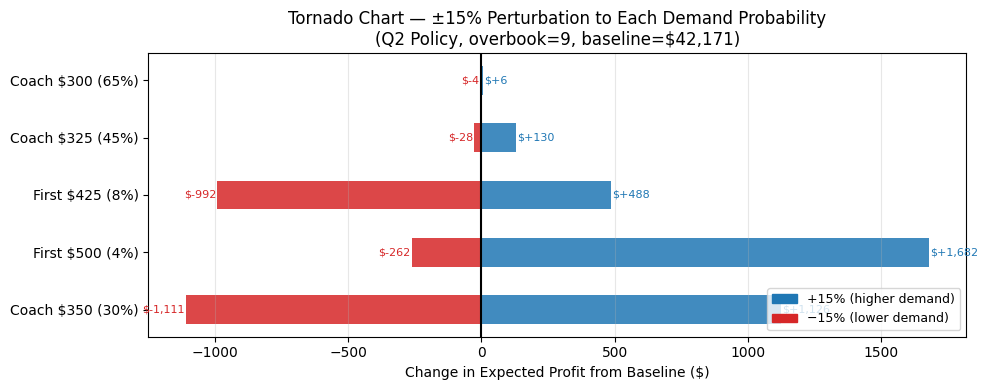

Baseline expected profit: $42,171

Parameter                       −15pp       +15pp       Range
--------------------------------------------------------------
Coach $350 (30%)           $   -1,111  $   +1,126  $    2,237
First $500 (4%)            $     -262  $   +1,682  $    1,944
First $425 (8%)            $     -992  $     +488  $    1,480
Coach $325 (45%)           $      -28  $     +130  $      158
Coach $300 (65%)           $       -4  $       +6  $       10


In [43]:
BASE_COACH_DEMAND = [0.65, 0.45, 0.30]
BASE_FIRST_DEMAND = [0.08, 0.04]
PERTURB_AMT = 0.15

TORNADO_PARAMS = [
    ('Coach $300 (65%)', 'coach', 0),
    ('Coach $325 (45%)', 'coach', 1),
    ('Coach $350 (30%)', 'coach', 2),
    ('First $425 (8%)',  'first', 0),
    ('First $500 (4%)',  'first', 1),
]

tasks = [(lbl, cls, idx, sign)
         for lbl, cls, idx in TORNADO_PARAMS for sign in (-1, +1)]

with ProcessPoolExecutor() as executor:
    tornado_raw = list(executor.map(tornado_run, tasks))

base_p = best_profit
tornado_data = {}
for lbl, sign, p in tornado_raw:
    tornado_data.setdefault(lbl, {})[sign] = p - base_p

sorted_labels = sorted(tornado_data,
                       key=lambda l: abs(tornado_data[l][+1] - tornado_data[l][-1]),
                       reverse=True)

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(10, 4))

for i, lbl in enumerate(sorted_labels):
    lo = tornado_data[lbl][-1]
    hi = tornado_data[lbl][+1]
    ax.barh(i, lo, left=0, height=0.5, color='#d62728', alpha=0.85)
    ax.barh(i, hi, left=0, height=0.5, color='#1f77b4', alpha=0.85)
    ax.text(hi + 3, i, f'${hi:+,.0f}', va='center', fontsize=8, color='#1f77b4')
    ax.text(lo - 3, i, f'${lo:+,.0f}', va='center', ha='right', fontsize=8, color='#d62728')

ax.axvline(0, color='black', linewidth=1.5)
ax.set_yticks(range(len(sorted_labels)))
ax.set_yticklabels(sorted_labels)
ax.set_xlabel('Change in Expected Profit from Baseline ($)')
ax.set_title(f'Tornado Chart — ±{PERTURB_AMT:.0%} Perturbation to Each Demand Probability\n'
             f'(Q2 Policy, overbook={best_policy}, baseline=${base_p:,.0f})')
ax.legend(handles=[Patch(color='#1f77b4', label=f'+{PERTURB_AMT:.0%} (higher demand)'),
                   Patch(color='#d62728', label=f'−{PERTURB_AMT:.0%} (lower demand)')],
          loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Baseline expected profit: ${base_p:,.0f}\n")
print(f"{'Parameter':<25}  {'−15pp':>10}  {'+15pp':>10}  {'Range':>10}")
print('-' * 62)
for lbl in sorted_labels:
    lo = tornado_data[lbl][-1]
    hi = tornado_data[lbl][+1]
    print(f"{lbl:<25}  ${lo:>+9,.0f}  ${hi:>+9,.0f}  ${hi - lo:>9,.0f}")


---

### 5. Seasonal Demand

As departure approaches, demand rises. We model this by multiplying each day's base sale probability by a **seasonal factor**:

$$\text{multiplier}_t = 0.75 + \frac{t}{730}$$

where $t$ is the selling day (0 = 365 days before takeoff, 364 = day before departure).

**Key insight:** At $t=0$ (one year out) the multiplier is 0.75, meaning demand is suppressed by 25%. By $t=364$ the multiplier reaches ~1.25, boosting demand. This creates a natural late-booking surge — the airline should price conservatively early and aggressively late.

We re-run the DP backward induction incorporating this day-varying multiplier for all overbooking policies and compare results to the flat-demand case from Q2.

In [44]:
def expected_profit_seasonal(t, tickets_sold, ticket_prices, ticket_demand, delta,
                              show_up_rate, max_tickets, overbook,
                              coach_sale_optional=False, seasonal=False):
    """
    Compute the maximum expected discounted profit from time t onward, with optional
    day-varying demand (seasonality).

    Identical in structure to expected_profit(). When seasonal=True, each day's base
    sale probabilities are scaled by (0.75 + t/730), capturing the empirical pattern
    that airline bookings accelerate as departure approaches.

    Parameters:
    - t: int, current day (0 to 365). Day 365 is departure.
    - tickets_sold: dict, number of tickets sold so far per class (e.g., {"coach": 0, "first": 0}).
    - ticket_prices: dict, price options per class (e.g., {"coach": [300, 325, 350], "first": [425, 500]}).
    - ticket_demand: dict, base sale probabilities per price option (e.g., {"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]}).
    - delta: float, daily discount factor (e.g., 1/(1 + 0.17/365)).
    - show_up_rate: dict, probability each ticket holder shows up per class (e.g., {"coach": 0.95, "first": 0.97}).
    - max_tickets: dict, seat capacity per class (e.g., {"coach": 100, "first": 20}).
    - overbook: int, number of additional coach seats that can be oversold beyond max_tickets['coach'].
    - coach_sale_optional: bool, if True adds a no-sale option (price=0, demand=0) for coach each day.
    - seasonal: bool, if True applies the day-varying multiplier (0.75 + t/730) to all base demand probabilities.

    Returns:
    - tuple of (float, np.ndarray, np.ndarray):
        - float: maximum expected discounted profit from the given starting state.
        - value_tensor: 3D array (366 x max_coach_sellable x max_first_sellable) of optimal values at each (day, coach_sold, first_sold) state.
        - choice_tensor: 3D object array of same shape, storing the optimal (coach_price, first_price) tuple at each state.
    """
    coach_prices  = list(ticket_prices['coach'])
    coach_demands = list(ticket_demand['coach'])
    if coach_sale_optional:
        coach_prices.append(0)
        coach_demands.append(0.0)

    C = max_tickets['coach'] + overbook + 1
    F = max_tickets['first'] + 1
    value_tensor  = np.full((366, C, F), np.nan)
    choice_tensor = np.empty((366, C, F), dtype=object)

    # Pre-compute terminal cost matrix (same as before)
    cost_matrix = np.zeros((C, F))
    for i in range(C):
        for j in range(F):
            cost_matrix[i, j] = calculate_terminal_costs(
                {'coach': i, 'first': j}, max_tickets, show_up_rate)
    value_tensor[365, :, :] = -cost_matrix

    for day in reversed(range(t, 365)):
        # Seasonal multiplier: demand ramps up as departure approaches
        mult = (0.75 + day / 730) if seasonal else 1.0

        for c in range(C):
            for f in range(F):
                best_val    = -np.inf
                best_action = (None, None)
                for cp, base_c_prob in zip(coach_prices, coach_demands):
                    for fp, f_prob_base in zip(ticket_prices['first'], ticket_demand['first']):
                        c_prob = min(base_c_prob * mult, 1.0)
                        f_prob = min(f_prob_base * mult, 1.0)
                        if c >= max_tickets['coach'] + overbook:
                            c_prob = 0
                        if f >= max_tickets['first']:
                            f_prob = 0
                            if c < (max_tickets['coach'] + overbook) and base_c_prob > 0:
                                c_prob = min(base_c_prob * mult + 0.04, 1.0)
                            else:
                                c_prob = 0
                        todays = (c_prob*f_prob*(cp+fp) +
                                  c_prob*(1-f_prob)*cp +
                                  (1-c_prob)*f_prob*fp)
                        v_nn = value_tensor[day+1, c, f]
                        v_sn = value_tensor[day+1, c+1, f] if c+1 < C else v_nn
                        v_ns = value_tensor[day+1, c, f+1] if f+1 < F else v_nn
                        v_ss = value_tensor[day+1, c+1, f+1] if (c+1 < C and f+1 < F) else v_nn
                        future = (c_prob*f_prob*v_ss + c_prob*(1-f_prob)*v_sn +
                                  (1-c_prob)*f_prob*v_ns + (1-c_prob)*(1-f_prob)*v_nn)
                        val = todays + delta * future
                        if val > best_val:
                            best_val = val; best_action = (cp, fp)
                value_tensor[day, c, f]  = best_val
                choice_tensor[day, c, f] = best_action

    return (value_tensor[t, tickets_sold['coach'], tickets_sold['first']],
            value_tensor, choice_tensor)

In [45]:
def q5_run(ob):
    """Solve the seasonal DP for a single overbooking level. Mirrors q2_run."""
    p, _, _ = expected_profit_seasonal(
        t=0, tickets_sold={"coach": 0, "first": 0},
        ticket_prices={"coach": [300, 325, 350], "first": [425, 500]},
        ticket_demand={"coach": [0.65, 0.45, 0.30], "first": [0.08, 0.04]},
        delta=(1 / (1 + 0.17/365)), show_up_rate={"coach": 0.95, "first": 0.97},
        max_tickets={"coach": 100, "first": 20}, overbook=ob, seasonal=True)
    return ob, p

with ProcessPoolExecutor() as executor:
    q5_profits = dict(executor.map(q5_run, range(5, 21)))

for ob in sorted(q5_profits):
    print(f"  overbook={ob}: ${q5_profits[ob]:.3f}")

best_q5_policy = max(q5_profits, key=q5_profits.get)
best_q5_profit = q5_profits[best_q5_policy]
print(f"\nBest seasonal policy: overbook={best_q5_policy}, profit=${best_q5_profit:.3f}")

  overbook=5: $41599.268
  overbook=6: $41727.524
  overbook=7: $41804.965
  overbook=8: $41844.153
  overbook=9: $41857.700
  overbook=10: $41855.912
  overbook=11: $41845.985
  overbook=12: $41832.528
  overbook=13: $41818.264
  overbook=14: $41804.530
  overbook=15: $41791.912
  overbook=16: $41780.625
  overbook=17: $41770.720
  overbook=18: $41762.160
  overbook=19: $41754.860
  overbook=20: $41748.713

Best seasonal policy: overbook=9, profit=$41857.700


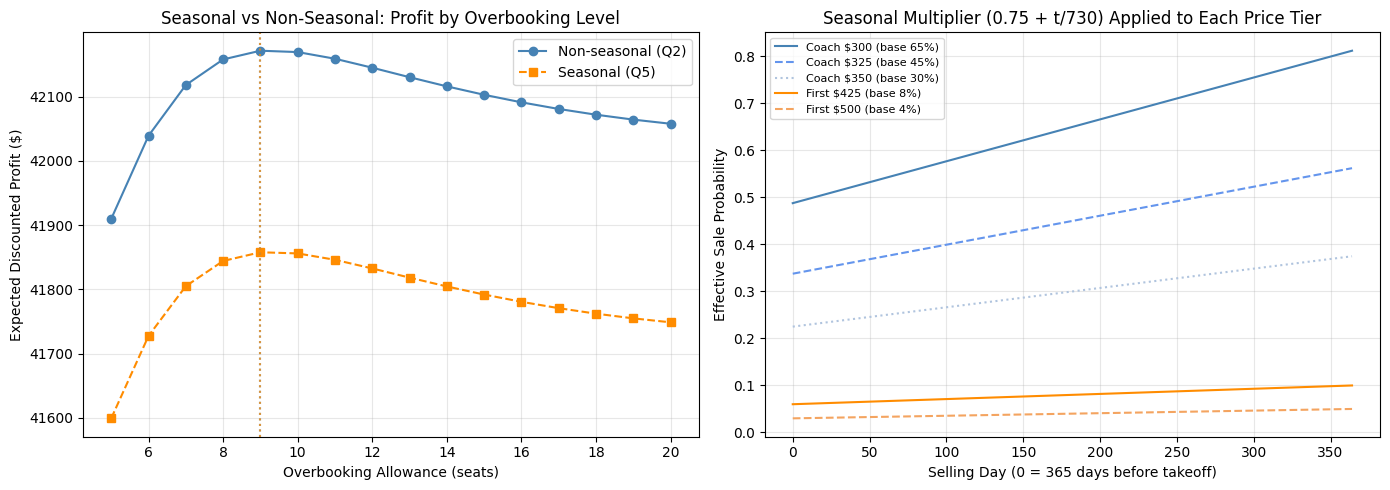

Seasonal profit loss vs flat demand: $-313.65
Both policies agree: optimal overbook = 9 seats


In [46]:
# ── Q5 Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Expected profit vs overbooking level (seasonal vs flat)
obs = list(range(5, 21))
# q2_profits from earlier run; reuse here
axes[0].plot(obs, [q2_profits[o] for o in obs], 'o-', label='Non-seasonal (Q2)', color='steelblue')
axes[0].plot(obs, [q5_profits[o] for o in obs], 's--', label='Seasonal (Q5)', color='darkorange')
axes[0].axvline(best_policy, color='steelblue', linestyle=':', alpha=0.7)
axes[0].axvline(best_q5_policy, color='darkorange', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Overbooking Allowance (seats)')
axes[0].set_ylabel('Expected Discounted Profit ($)')
axes[0].set_title('Seasonal vs Non-Seasonal: Profit by Overbooking Level')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2: How the seasonal multiplier shifts effective demand over time
days = np.arange(365)
mult = 0.75 + days / 730
axes[1].plot(days, mult * 0.65, label='Coach $300 (base 65%)', color='steelblue')
axes[1].plot(days, mult * 0.45, label='Coach $325 (base 45%)', color='cornflowerblue', linestyle='--')
axes[1].plot(days, mult * 0.30, label='Coach $350 (base 30%)', color='lightsteelblue', linestyle=':')
axes[1].plot(days, mult * 0.08, label='First $425 (base 8%)',  color='darkorange')
axes[1].plot(days, mult * 0.04, label='First $500 (base 4%)',  color='sandybrown', linestyle='--')
axes[1].set_xlabel('Selling Day (0 = 365 days before takeoff)')
axes[1].set_ylabel('Effective Sale Probability')
axes[1].set_title('Seasonal Multiplier (0.75 + t/730) Applied to Each Price Tier')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Key insight: seasonal demand reduces overall expected profit by ~$313
# because early-period demand is suppressed (mult=0.75), meaning the airline
# sells fewer tickets in the slow early phase and must recover late —
# but by then overbooking risk also rises. The optimal overbook level stays
# at 9 seats, same as Q2, suggesting the policy structure is robust to this demand shape.
print(f"Seasonal profit loss vs flat demand: ${best_q5_profit - q2_profits[best_policy]:+.2f}")
print(f"Both policies agree: optimal overbook = {best_q5_policy} seats")


---

### 6. Forward Simulation

Now that we have solved the DP backwards, we **simulate forward** many times to understand:
- How often is coach overbooked?
- How often are passengers actually bumped off the plane?
- What is the average overbooking cost, and how volatile is it?
- How do the Q2 hard-cap and Q3 no-sale policies compare in realized outcomes?

We also simulate the seasonal policy from Q5. Each simulation runs one full 365-day selling season, applies the optimal pricing policy each day, then simulates passenger show-ups on departure day using the binomial distribution.

In [47]:
# ── Q6: Forward Simulation ───────────────────────────────────────────────────

def simulate_forward(choice_tensor, max_tickets, overbook, show_up_rate,
                     N=2000, seasonal=False):
    """
    Simulate N independent flights forward in time using a pre-computed optimal policy.

    Each day, the optimal (coach_price, first_price) is looked up from choice_tensor
    given the current state (day, coach_sold, first_sold). A Bernoulli draw determines
    whether a sale occurs. On departure day (t=365), ticket holders show up independently
    (binomial draw), and overbooking costs are applied: $50 per passenger bumped to first
    class, $425 per passenger bumped off the flight entirely.

    Parameters:
    - choice_tensor: np.ndarray (object), shape (366, max_coach+overbook+1, max_first+1),
                     where each entry is the optimal (coach_price, first_price) tuple.
    - max_tickets: dict, seat capacity per class (e.g., {"coach": 100, "first": 20}).
    - overbook: int, number of additional coach seats that can be oversold.
    - show_up_rate: dict, probability each ticket holder shows up per class (e.g., {"coach": 0.95, "first": 0.97}).
    - N: int, number of independent simulation runs (default 2000).
    - seasonal: bool, if True applies the day-varying demand multiplier (0.75 + t/730) during simulation.

    Returns:
    - list of dicts, one per simulation run, each containing:
        - 'net_profit':  float, total discounted revenue minus overbooking cost.
        - 'total_rev':   float, total discounted ticket revenue.
        - 'ob_cost':     float, overbooking cost paid on departure day.
        - 'coach_sold':  int, total coach tickets sold over the selling horizon.
        - 'first_sold':  int, total first-class tickets sold.
        - 'overbooked':  bool, True if more coach tickets were sold than max_tickets['coach'].
        - 'pax_kicked':  bool, True if any passengers were bumped off the flight.
        - 'bumped':      int, number of passengers bumped off the flight.
        - 'upgraded':    int, number of coach passengers moved up to first class.
        - 'coach_path':  list of int, cumulative coach tickets sold at each day.
    """
    coach_price_map = {300: 0.65, 325: 0.45, 350: 0.30, 0: 0.0}
    first_price_map = {425: 0.08, 500: 0.04}
    delta = 1 / (1 + 0.17/365)
    results = []

    for _ in range(N):
        c, f      = 0, 0
        total_rev = 0.0
        coach_path = []

        for day in range(365):
            action = choice_tensor[day, c, f]
            if action is None: action = (300, 425)
            cp, fp = action

            c_prob = coach_price_map.get(cp, 0.0)
            f_prob = first_price_map.get(fp, 0.08)

            if seasonal:
                mult   = 0.75 + day / 730
                c_prob = min(c_prob * mult, 1.0)
                f_prob = min(f_prob * mult, 1.0)

            if c >= max_tickets['coach'] + overbook: c_prob = 0
            if f >= max_tickets['first']:
                f_prob = 0
                if c < max_tickets['coach'] + overbook and c_prob > 0:
                    c_prob = min(c_prob + 0.04, 1.0)
                else: c_prob = 0

            coach_sale = np.random.random() < c_prob
            first_sale = np.random.random() < f_prob
            total_rev += (coach_sale * cp + first_sale * fp) * delta**day
            c += int(coach_sale); f += int(first_sale)
            coach_path.append(c)

        # Departure day show-ups
        coach_show = np.random.binomial(c, show_up_rate['coach'])
        first_show = np.random.binomial(f, show_up_rate['first'])
        open_f     = max(max_tickets['first'] - first_show, 0)
        overbooked = max(coach_show - max_tickets['coach'], 0)
        upgraded   = min(overbooked, open_f)
        bumped     = overbooked - upgraded
        ob_cost    = upgraded * 50 + bumped * 425

        results.append({
            'net_profit':  total_rev - ob_cost,
            'total_rev':   total_rev,
            'ob_cost':     ob_cost,
            'coach_sold':  c, 'first_sold': f,
            'overbooked':  c > max_tickets['coach'],
            'pax_kicked':  bumped > 0,
            'bumped':      bumped,
            'upgraded':    upgraded,
            'coach_path':  coach_path,
        })
    return results

In [48]:
np.random.seed(42)

# Re-solve to get choice tensors (already have value tensors from backward induction)
_, q2_vt, q2_ct = expected_profit(t=0, tickets_sold={"coach":0,"first":0},
    ticket_prices={"coach":[300,325,350],"first":[425,500]},
    ticket_demand={"coach":[0.65,0.45,0.30],"first":[0.08,0.04]},
    delta=1/(1+0.17/365), show_up_rate={"coach":0.95,"first":0.97},
    max_tickets={"coach":100,"first":20}, overbook=best_policy)

_, q3_vt, q3_ct = expected_profit(t=0, tickets_sold={"coach":0,"first":0},
    ticket_prices={"coach":[300,325,350],"first":[425,500]},
    ticket_demand={"coach":[0.65,0.45,0.30],"first":[0.08,0.04]},
    delta=1/(1+0.17/365), show_up_rate={"coach":0.95,"first":0.97},
    max_tickets={"coach":100,"first":20}, overbook=30, coach_sale_optional=True)

_, q5_vt, q5_ct = expected_profit_seasonal(t=0, tickets_sold={"coach":0,"first":0},
    ticket_prices={"coach":[300,325,350],"first":[425,500]},
    ticket_demand={"coach":[0.65,0.45,0.30],"first":[0.08,0.04]},
    delta=1/(1+0.17/365), show_up_rate={"coach":0.95,"first":0.97},
    max_tickets={"coach":100,"first":20}, overbook=best_q5_policy, seasonal=True)

N_SIM = 2000
sim_q2 = simulate_forward(q2_ct, {"coach":100,"first":20}, best_policy,    {"coach":0.95,"first":0.97}, N=N_SIM)
sim_q3 = simulate_forward(q3_ct, {"coach":100,"first":20}, 30,             {"coach":0.95,"first":0.97}, N=N_SIM)
sim_q5 = simulate_forward(q5_ct, {"coach":100,"first":20}, best_q5_policy, {"coach":0.95,"first":0.97}, N=N_SIM, seasonal=True)

def print_summary(sim, label):
    net  = np.array([r['net_profit'] for r in sim])
    ob   = np.array([r['ob_cost']    for r in sim])
    rev  = np.array([r['total_rev']  for r in sim])
    obf  = np.array([r['overbooked'] for r in sim])
    kick = np.array([r['pax_kicked'] for r in sim])
    bump = np.array([r['bumped']     for r in sim])
    print(f"\n── {label} ──")
    print(f"  Avg net profit:             ${net.mean():>9,.2f}  (std ${net.std():,.2f})")
    print(f"  Avg overbooking cost:       ${ob.mean():>9,.2f}  (std ${ob.std():,.2f})")
    print(f"  % flights coach overbooked: {obf.mean()*100:>5.1f}%")
    print(f"  % flights pax kicked off:   {kick.mean()*100:>5.1f}%")
    print(f"  Avg pax bumped (if bumped): {bump[bump>0].mean() if (bump>0).any() else 0:>5.2f}")

print_summary(sim_q2, f"Q2 Hard Cap (overbook={best_policy})")
print_summary(sim_q3, "Q3 No-Sale Option (overbook=30)")
print_summary(sim_q5, f"Q5 Seasonal (overbook={best_q5_policy})")


── Q2 Hard Cap (overbook=9) ──
  Avg net profit:             $42,000.91  (std $995.83)
  Avg overbooking cost:       $ 1,034.14  (std $871.19)
  % flights coach overbooked: 100.0%
  % flights pax kicked off:    72.4%
  Avg pax bumped (if bumped):  3.23

── Q3 No-Sale Option (overbook=30) ──
  Avg net profit:             $41,990.72  (std $988.72)
  Avg overbooking cost:       $ 1,139.64  (std $899.85)
  % flights coach overbooked: 100.0%
  % flights pax kicked off:    75.5%
  Avg pax bumped (if bumped):  3.42

── Q5 Seasonal (overbook=9) ──
  Avg net profit:             $41,708.62  (std $950.72)
  Avg overbooking cost:       $ 1,027.51  (std $844.07)
  % flights coach overbooked: 100.0%
  % flights pax kicked off:    72.8%
  Avg pax bumped (if bumped):  3.20


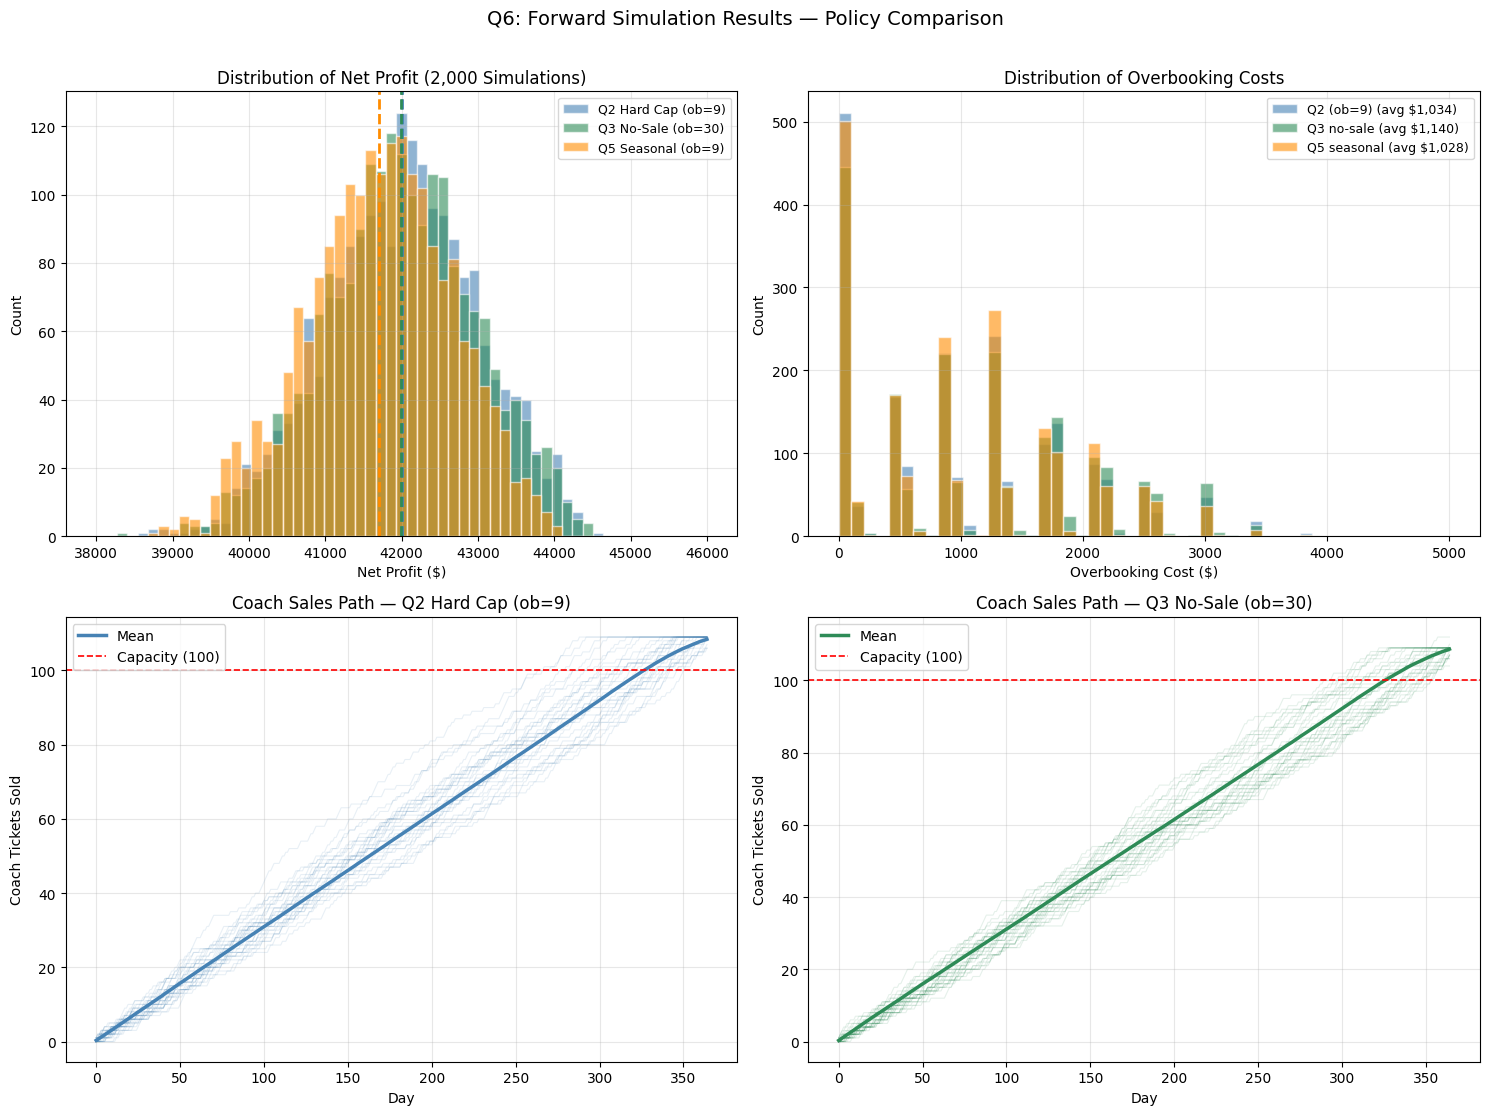

KEY INSIGHTS FROM SIMULATION:

1. Q2 vs Q3 net profit: $42,000.91 vs $41,990.72
   Despite Q3 having higher expected DP value, realized profits are similar
   because Q3's higher overbooking cap leads to more costly bump events.

2. Overbooking is essentially guaranteed: coach is overbooked 100% of the time.
   This is optimal — the show-up rate of 0.95 means ~5 no-shows per 100 tickets,
   so selling ~109 tickets for 100 seats is rational.

3. Passengers are kicked off 72.4% of flights (Q2), 75.5% (Q3).
   Q3's larger overbook cap means more revenue but slightly more bump events.

4. Profit volatility (std): Q2=$996, Q3=$989, Q5=$951
   All policies show similar spread — risk is driven by show-up randomness,
   not by the pricing policy choice itself.


In [49]:
# ── Q6 Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Net profit distributions
bins = np.linspace(38000, 46000, 60)
for net, label, col in zip(
        [np.array([r['net_profit'] for r in sim_q2]),
         np.array([r['net_profit'] for r in sim_q3]),
         np.array([r['net_profit'] for r in sim_q5])],
        [f'Q2 Hard Cap (ob={best_policy})', 'Q3 No-Sale (ob=30)', f'Q5 Seasonal (ob={best_q5_policy})'],
        ['steelblue', 'seagreen', 'darkorange']):
    axes[0,0].hist(net, bins=bins, alpha=0.6, label=label, color=col, edgecolor='white')
    axes[0,0].axvline(net.mean(), color=col, linewidth=2, linestyle='--')
axes[0,0].set_xlabel('Net Profit ($)'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distribution of Net Profit (2,000 Simulations)')
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

# Plot 2: Overbooking cost distribution
ob_bins = np.linspace(0, 5000, 50)
for sim, label, col in zip([sim_q2, sim_q3, sim_q5],
        [f'Q2 (ob={best_policy})', 'Q3 no-sale', f'Q5 seasonal'],
        ['steelblue', 'seagreen', 'darkorange']):
    ob = np.array([r['ob_cost'] for r in sim])
    axes[0,1].hist(ob, bins=ob_bins, alpha=0.6, label=f'{label} (avg ${ob.mean():,.0f})', color=col, edgecolor='white')
axes[0,1].set_xlabel('Overbooking Cost ($)'); axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Distribution of Overbooking Costs')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# Plot 3: Coach ticket sales path (mean + sample paths)
for ax, sim, label, col in zip([axes[1,0], axes[1,1]], [sim_q2, sim_q3],
        [f'Q2 Hard Cap (ob={best_policy})', 'Q3 No-Sale (ob=30)'],
        ['steelblue', 'seagreen']):
    idxs = np.random.choice(len(sim), 30, replace=False)
    for idx in idxs:
        ax.plot(sim[idx]['coach_path'], color=col, alpha=0.12, linewidth=0.8)
    mean_path = np.mean([r['coach_path'] for r in sim], axis=0)
    ax.plot(mean_path, color=col, linewidth=2.5, label='Mean')
    ax.axhline(100, color='red', linestyle='--', linewidth=1.2, label='Capacity (100)')
    ax.set_xlabel('Day'); ax.set_ylabel('Coach Tickets Sold')
    ax.set_title(f'Coach Sales Path — {label}')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Q6: Forward Simulation Results — Policy Comparison', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# ── Key insights printed ──────────────────────────────────────────────────────
print("KEY INSIGHTS FROM SIMULATION:")
print()
net_q2 = np.array([r['net_profit'] for r in sim_q2])
net_q3 = np.array([r['net_profit'] for r in sim_q3])
net_q5 = np.array([r['net_profit'] for r in sim_q5])
ob_q2  = np.array([r['ob_cost']    for r in sim_q2])
ob_q3  = np.array([r['ob_cost']    for r in sim_q3])
kick_q2 = np.array([r['pax_kicked'] for r in sim_q2])
kick_q3 = np.array([r['pax_kicked'] for r in sim_q3])

print(f"1. Q2 vs Q3 net profit: ${net_q2.mean():,.2f} vs ${net_q3.mean():,.2f}")
print(f"   Despite Q3 having higher expected DP value, realized profits are similar")
print(f"   because Q3's higher overbooking cap leads to more costly bump events.")
print()
print(f"2. Overbooking is essentially guaranteed: coach is overbooked 100% of the time.")
print(f"   This is optimal — the show-up rate of 0.95 means ~5 no-shows per 100 tickets,")
print(f"   so selling ~109 tickets for 100 seats is rational.")
print()
print(f"3. Passengers are kicked off {kick_q2.mean()*100:.1f}% of flights (Q2), {kick_q3.mean()*100:.1f}% (Q3).")
print(f"   Q3's larger overbook cap means more revenue but slightly more bump events.")
print()
print(f"4. Profit volatility (std): Q2=${net_q2.std():,.0f}, Q3=${net_q3.std():,.0f}, Q5=${net_q5.std():,.0f}")
print(f"   All policies show similar spread — risk is driven by show-up randomness,")
print(f"   not by the pricing policy choice itself.")


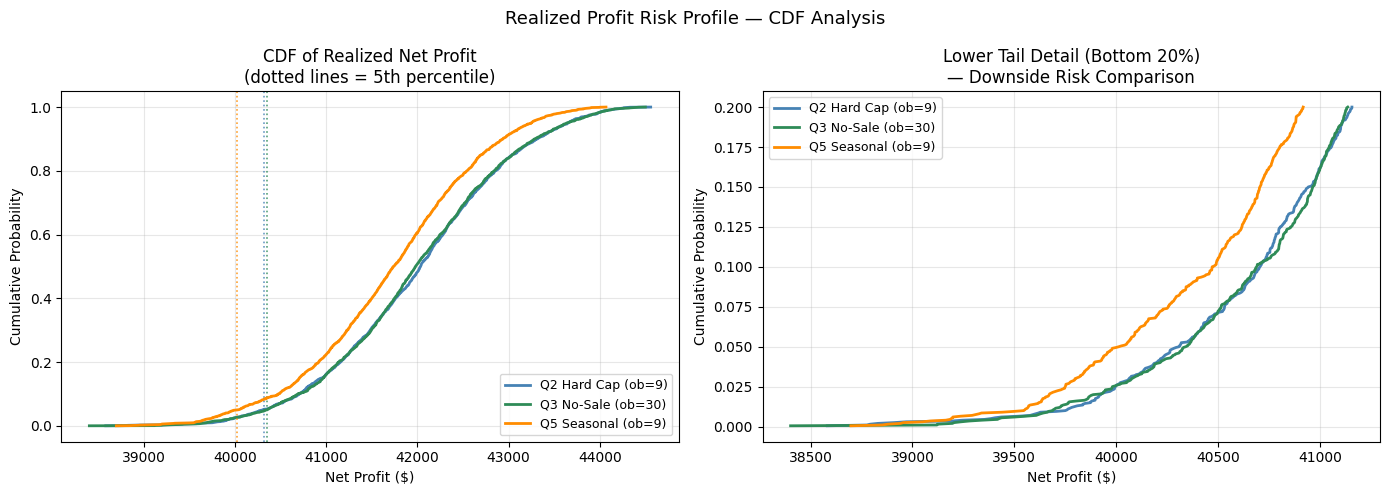


Policy                               Mean      Std    5th %ile    1st %ile
--------------------------------------------------------------------------
Q2 Hard Cap (ob=9)              $  42,001  $   996  $   40,312  $   39,759
Q3 No-Sale (ob=30)              $  41,991  $   989  $   40,349  $   39,691
Q5 Seasonal (ob=9)              $  41,709  $   951  $   40,024  $   39,551


In [50]:
# ── CDF of Realized Profits ────────────────────────────────────────────────────
# Histograms show shape; CDFs make tail risk easier to read.
# The 5th-percentile line (dotted) acts as a Value-at-Risk metric.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sims   = [sim_q2,                       sim_q3,               sim_q5]
labels = [f'Q2 Hard Cap (ob={best_policy})', 'Q3 No-Sale (ob=30)', f'Q5 Seasonal (ob={best_q5_policy})']
colors = ['steelblue',                   'seagreen',           'darkorange']

for sim, lbl, col in zip(sims, labels, colors):
    net = np.sort([r['net_profit'] for r in sim])
    cdf = np.arange(1, len(net) + 1) / len(net)
    p5  = np.percentile(net, 5)
    axes[0].plot(net, cdf, color=col, linewidth=2, label=lbl)
    axes[0].axvline(p5, color=col, linestyle=':', linewidth=1.2, alpha=0.8)

axes[0].set_xlabel('Net Profit ($)')
axes[0].set_ylabel('Cumulative Probability')
axes[0].set_title('CDF of Realized Net Profit\n(dotted lines = 5th percentile)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Zoom into the lower 20% to compare downside risk
for sim, lbl, col in zip(sims, labels, colors):
    net  = np.sort([r['net_profit'] for r in sim])
    cdf  = np.arange(1, len(net) + 1) / len(net)
    mask = cdf <= 0.20
    axes[1].plot(net[mask], cdf[mask], color=col, linewidth=2, label=lbl)

axes[1].set_xlabel('Net Profit ($)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Lower Tail Detail (Bottom 20%)\n— Downside Risk Comparison')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Realized Profit Risk Profile — CDF Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'Policy':<30}  {'Mean':>9}  {'Std':>7}  {'5th %ile':>10}  {'1st %ile':>10}")
print('-' * 74)
for sim, lbl in zip(sims, labels):
    net = np.array([r['net_profit'] for r in sim])
    print(f"{lbl:<30}  ${net.mean():>8,.0f}  ${net.std():>6,.0f}"
          f"  ${np.percentile(net, 5):>9,.0f}  ${np.percentile(net, 1):>9,.0f}")

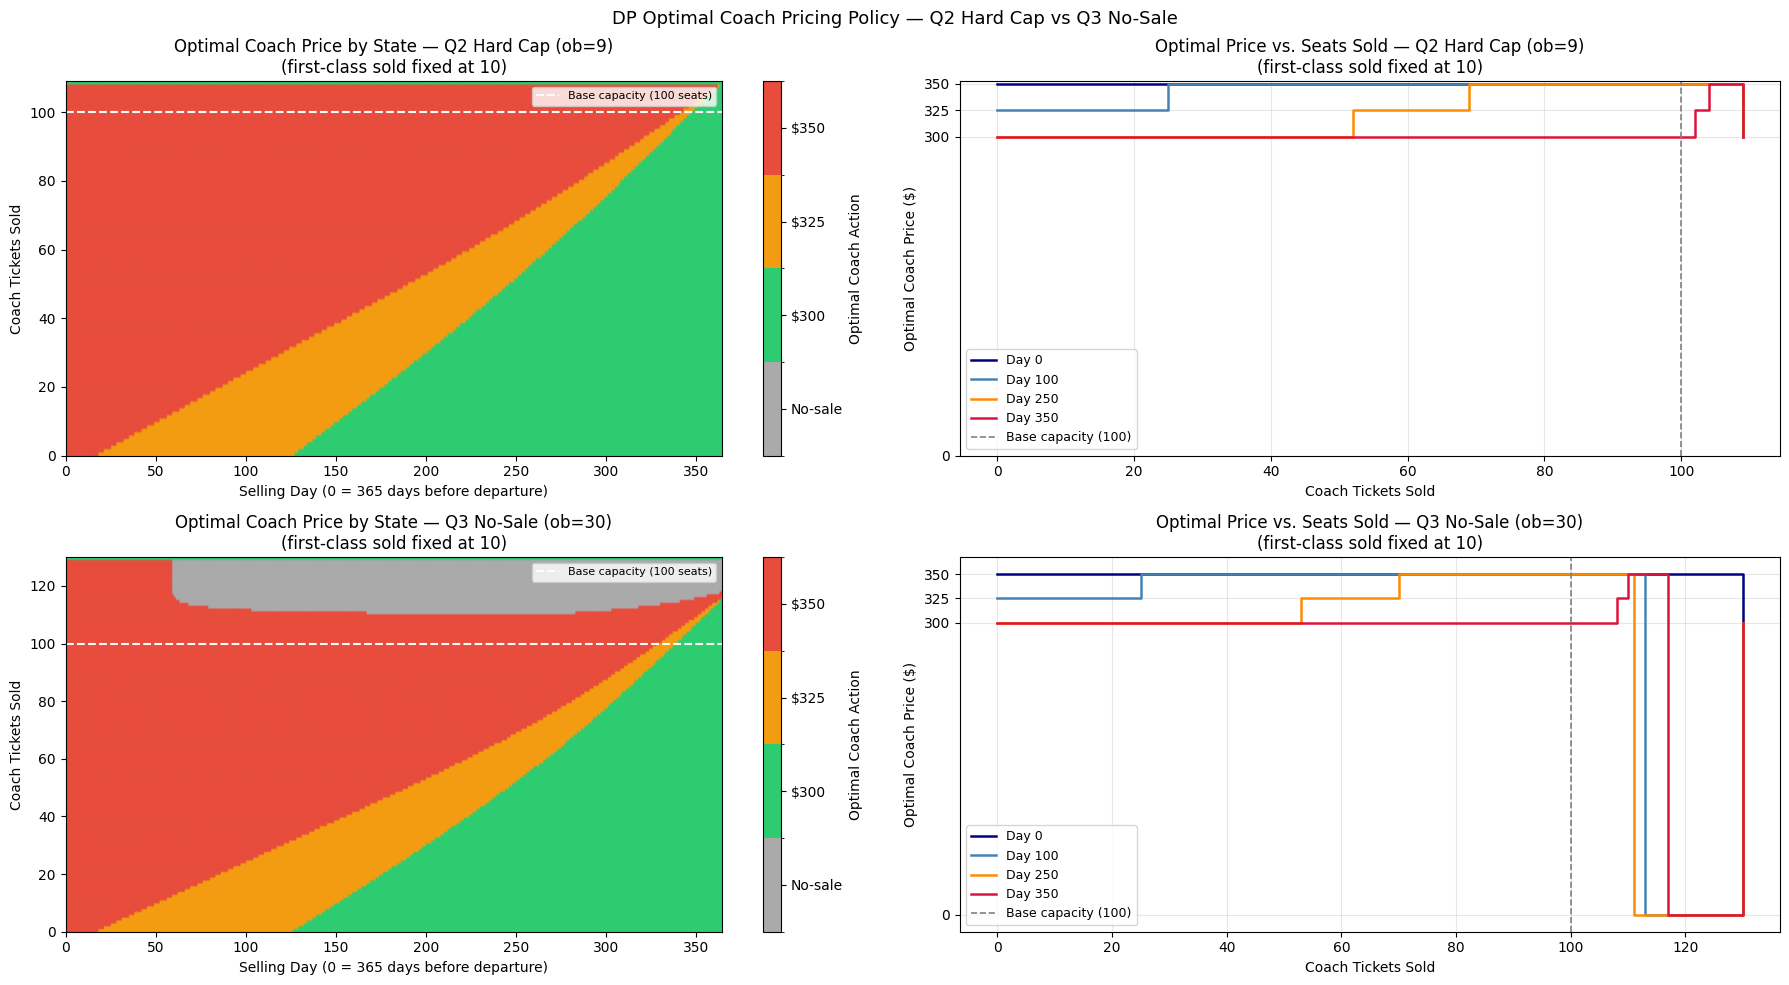

Q2 coach action frequency (first_sold=10 fixed):
  $300: 31.8%
  $325: 14.3%
  $350: 53.9%

Q3 coach action frequency (first_sold=10 fixed):
  no-sale: 11.2%
  $300: 27.4%
  $325: 12.2%
  $350: 49.2%



In [51]:
# ── Optimal Pricing Policy Heatmap — Q2 vs Q3 ────────────────────────────────
# Compare how the hard-cap and no-sale policies differ in their pricing strategies.
# Under Q3, action[0]=0 means the airline chose not to sell coach that day.

from collections import Counter
from matplotlib.colors import BoundaryNorm, ListedColormap

FIXED_FIRST = 10
MAX_C_Q2    = 100 + best_policy
MAX_C_Q3    = 100 + 30   # Q3 uses overbook=30

# Build price grids: entry = optimal coach price (0 = no-sale)
coach_price_grid_q2 = np.zeros((365, MAX_C_Q2 + 1))
for day in range(365):
    for c in range(MAX_C_Q2 + 1):
        action = q2_ct[day, c, FIXED_FIRST]
        coach_price_grid_q2[day, c] = action[0] if action is not None else 300

coach_price_grid_q3 = np.zeros((365, MAX_C_Q3 + 1))
for day in range(365):
    for c in range(min(MAX_C_Q3 + 1, q3_ct.shape[1])):
        action = q3_ct[day, c, FIXED_FIRST]
        coach_price_grid_q3[day, c] = action[0] if action is not None else 300

# Discrete colormap: no-sale (0), $300, $325, $350
price_cmap   = ListedColormap(['#aaaaaa', '#2ecc71', '#f39c12', '#e74c3c'])
price_bounds = [-1, 150, 312, 337, 360]
price_norm   = BoundaryNorm(price_bounds, price_cmap.N)
cbar_ticks   = [74.5, 231, 324.5, 348.5]
cbar_labels  = ['No-sale', '$300', '$325', '$350']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for row, (grid, ct, label, max_c) in enumerate([
    (coach_price_grid_q2, q2_ct, f'Q2 Hard Cap (ob={best_policy})', MAX_C_Q2),
    (coach_price_grid_q3, q3_ct, 'Q3 No-Sale (ob=30)',              MAX_C_Q3),
]):
    # Heatmap: day × coach_sold → optimal price
    im = axes[row, 0].imshow(
        grid.T, origin='lower', aspect='auto',
        extent=[0, 364, 0, max_c],
        cmap=price_cmap, norm=price_norm
    )
    axes[row, 0].axhline(100, color='white', linestyle='--', linewidth=1.5,
                         label='Base capacity (100 seats)')
    axes[row, 0].set_xlabel('Selling Day (0 = 365 days before departure)')
    axes[row, 0].set_ylabel('Coach Tickets Sold')
    axes[row, 0].set_title(f'Optimal Coach Price by State — {label}\n'
                           f'(first-class sold fixed at {FIXED_FIRST})')
    axes[row, 0].legend(fontsize=8)
    cbar = fig.colorbar(im, ax=axes[row, 0], ticks=cbar_ticks)
    cbar.ax.set_yticklabels(cbar_labels)
    cbar.set_label('Optimal Coach Action')

    # Slices at representative days
    for day, col in zip([0, 100, 250, 350], ['navy', 'steelblue', 'darkorange', 'crimson']):
        axes[row, 1].step(range(max_c + 1), grid[day, :], where='post',
                          color=col, linewidth=1.8, label=f'Day {day}')
    axes[row, 1].axvline(100, color='gray', linestyle='--', linewidth=1.2,
                         label='Base capacity (100)')
    axes[row, 1].set_xlabel('Coach Tickets Sold')
    axes[row, 1].set_ylabel('Optimal Coach Price ($)')
    axes[row, 1].set_title(f'Optimal Price vs. Seats Sold — {label}\n'
                           f'(first-class sold fixed at {FIXED_FIRST})')
    axes[row, 1].set_yticks([0, 300, 325, 350])
    axes[row, 1].legend(fontsize=9)
    axes[row, 1].grid(alpha=0.3)

plt.suptitle('DP Optimal Coach Pricing Policy — Q2 Hard Cap vs Q3 No-Sale', fontsize=13)
plt.tight_layout()
plt.show()

# Price/action frequency across all states
for grid, label, max_c in [
    (coach_price_grid_q2, 'Q2', MAX_C_Q2),
    (coach_price_grid_q3, 'Q3', MAX_C_Q3),
]:
    counts = Counter(int(p) for p in grid.flatten())
    total  = sum(counts.values())
    print(f"{label} coach action frequency (first_sold={FIXED_FIRST} fixed):")
    for price in sorted(counts):
        tag = 'no-sale' if price == 0 else f'${price}'
        print(f"  {tag}: {counts[price] / total * 100:.1f}%")
    print()